# 01 — Datos sintéticos: eigensolver y generadores M0/M1

Este notebook muestra el trabajo de las tareas **T09, T10 y T12**:

1. **Eigensolver de referencia** con elementos finitos de Hermite, que devuelve frecuencias y formas modales de una viga Euler–Bernoulli con carga axial.
2. **Validación (compuerta G1)**: el solver contra las soluciones analíticas, con error < 0.1%.
3. **Generadores M0** (empotramiento ideal) y **M1** (soporte elástico), con ruido relativo reproducible y guardado en el formato estándar `.npz`.

El código vive en `src/pinn_mems/` y las pruebas en `tests/` (`pytest`). Aquí solo se *usa* y se visualiza.

**La idea:** generamos datos con un modelo más completo (M1, soporte flexible) en el que conocemos el E verdadero. Después los métodos invierten esos datos con el modelo simple (empotramiento ideal) y medimos su sesgo.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

from pinn_mems import Conjunto, Soporte, Viga, cargar_config, generar, resolver_modos

# Paleta categórica fija: modo 1, 2, 3 (y voladizo, biempotrada)
COLORES = ["#2a78d6", "#eb6834", "#1baf7a"]
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
    "lines.linewidth": 2, "figure.dpi": 110,
})

## 1. La viga de referencia

Geometría del material de referencia **RM 8096** (NIST SP 260-177, tabla YM1): óxido de silicio, L = 300 µm, b = 28 µm, h = 2.743 µm, ρ = 2.2 g/cm³, E ≈ 70 GPa.

In [2]:
viga = Viga(E=70e9, L=300e-6, b=28e-6, h=2.743e-6, rho=2200.0, sigma0=0.0)

voladizo = resolver_modos(viga, "voladizo")
biempotrada = resolver_modos(viga, "biempotrada")
print("Voladizo     f =", np.round(voladizo.frecuencias_hz / 1e3, 2), "kHz")
print("Biempotrada  f =", np.round(biempotrada.frecuencias_hz / 1e3, 2), "kHz")

Voladizo     f = [ 27.77 174.04 487.32] kHz
Biempotrada  f = [176.72 487.13 954.97] kHz


## 2. Validación contra la solución analítica (G1)

Para empotramiento ideal, ω = (βL)²·√(EI / ρAL⁴), con raíces βL conocidas. La compuerta exige un error < 0.1%. Las mismas comparaciones, y otras (tensión, pandeo, límites del resorte), están automatizadas en `tests/test_eigensolver.py`.

In [3]:
raices = {
    "voladizo": [1.8751040687, 4.6940911330, 7.8547574382],
    "biempotrada": [4.7300407449, 7.8532046241, 10.9956078380],
}
escala = math.sqrt(viga.EI / (viga.rho * viga.A * viga.L**4))
for nombre, modos in [("voladizo", voladizo), ("biempotrada", biempotrada)]:
    analitica = np.array(raices[nombre]) ** 2 * escala
    error = np.abs(modos.omega / analitica - 1) * 100
    print(f"{nombre:12s} error relativo por modo: {np.array2string(error, precision=6)} %")

voladizo     error relativo por modo: [5.788997e-06 9.847811e-08 1.495607e-07] %
biempotrada  error relativo por modo: [7.449029e-08 1.493411e-07 6.299664e-07] %


### Formas modales

Normalizadas a amplitud pico 1. El signo es determinista: el primer valor no nulo desde ξ = 0 es positivo.

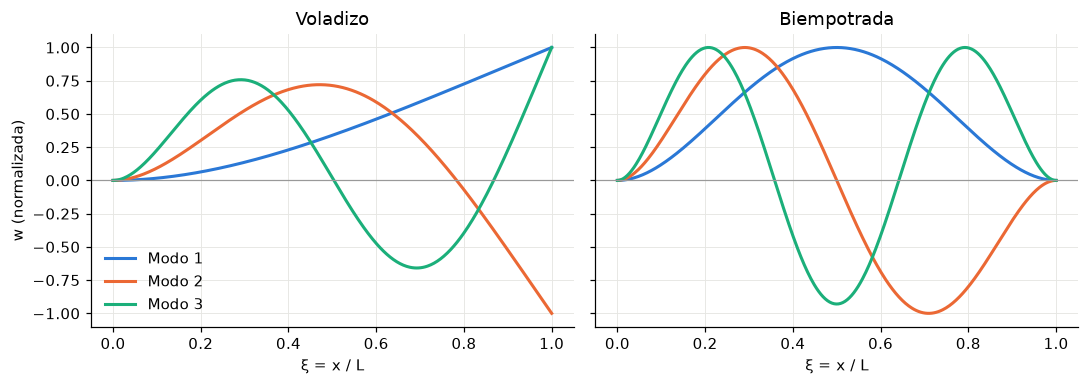

In [4]:
xi = np.linspace(0, 1, 400)
fig, ejes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for eje, (nombre, modos) in zip(ejes, [("Voladizo", voladizo), ("Biempotrada", biempotrada)]):
    w = modos.forma(xi)
    for m in range(3):
        eje.plot(xi, w[m], color=COLORES[m], label=f"Modo {m + 1}")
    eje.axhline(0, color="#999", linewidth=0.8)
    eje.set_title(nombre)
    eje.set_xlabel("ξ = x / L")
ejes[0].set_ylabel("w (normalizada)")
ejes[0].legend(frameon=False)
fig.tight_layout()

### Convergencia de malla

Los elementos de Hermite convergen rápido. Con 200 elementos (lo que usan los generadores) el error en ω₁ está muy por debajo de 0.01%. El error cae como 1/n⁴ hasta ≈10⁻⁹. Pasados ~100 elementos domina el redondeo de doble precisión y la curva se aplana o sube un poco, sin efecto práctico. Generar con una malla más fina que la de inversión evita el *crimen inverso*.

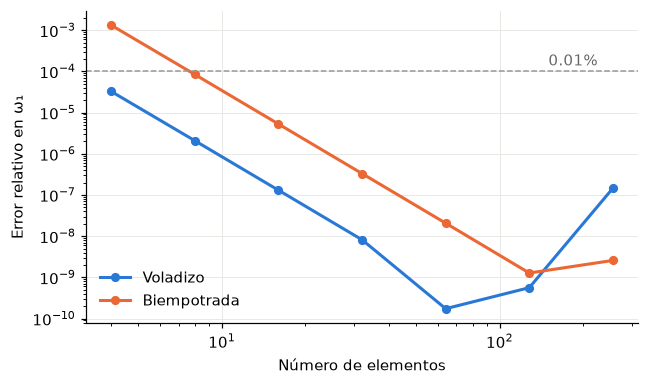

In [5]:
n_elems = [4, 8, 16, 32, 64, 128, 256]
fig, eje = plt.subplots(figsize=(6, 3.6))
for i, nombre in enumerate(["voladizo", "biempotrada"]):
    exacta = raices[nombre][0] ** 2 * escala
    err = [abs(resolver_modos(viga, nombre, n_elem=n).omega[0] / exacta - 1) for n in n_elems]
    eje.loglog(n_elems, err, "o-", color=COLORES[i], markersize=5, label=nombre.capitalize())
eje.axhline(1e-4, color="#999", linestyle="--", linewidth=1)
eje.text(150, 1.4e-4, "0.01%", color="#666")
eje.set_xlabel("Número de elementos")
eje.set_ylabel("Error relativo en ω₁")
eje.legend(frameon=False)
fig.tight_layout()

## 3. M1: cómo baja la frecuencia al ablandar el soporte

En M1 el soporte tiene un resorte rotacional κ_θ = k_θ·L/EI (y uno traslacional κ_u). Con κ → ∞ se recupera M0; al bajar κ_θ la viga se comporta como si fuera más larga y **ω₁ baja**. Esto valida el signo de las condiciones de frontera.

Si un método invierte la frecuencia con el modelo ideal, el E que extrae escala como ω², así que

  **sesgo en E ≈ (ω₁ᴹ¹ / ω₁ᴹ⁰)² − 1**

La línea punteada marca el ≈5% de sesgo en E reportado en la literatura de M-TEST. Esto es solo una vista previa: la calibración formal de los 6 puntos de severidad es la tarea **T13**.

voladizo     sesgo de −5% en E con κ_θ ≈ 77


biempotrada  sesgo de −5% en E con κ_θ ≈ 152


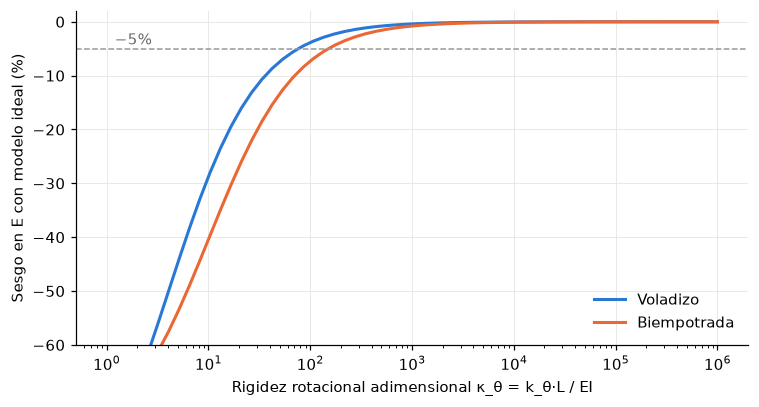

In [6]:
kappas = np.logspace(0, 6, 60)
fig, eje = plt.subplots(figsize=(7, 3.8))
for i, (nombre, m0) in enumerate([("voladizo", voladizo), ("biempotrada", biempotrada)]):
    w1 = np.array([resolver_modos(viga, nombre, Soporte(kappa_theta=k)).omega[0] for k in kappas])
    sesgo_E = (w1 / m0.omega[0]) ** 2 - 1
    eje.semilogx(kappas, 100 * sesgo_E, color=COLORES[i], label=nombre.capitalize())
    k5 = np.interp(-0.05, sesgo_E, kappas)  # sesgo_E crece con κ
    print(f"{nombre:12s} sesgo de −5% en E con κ_θ ≈ {k5:.0f}")
eje.axhline(-5, color="#999", linestyle="--", linewidth=1)
eje.text(1.2, -4.2, "−5%", color="#666")
eje.set_xlabel("Rigidez rotacional adimensional κ_θ = k_θ·L / EI")
eje.set_ylabel("Sesgo en E con modelo ideal (%)")
eje.set_ylim(-60, 2)
eje.legend(frameon=False)
fig.tight_layout()

## 4. Generar un conjunto desde su config

Cada conjunto se define con un YAML en `datos/sinteticos/configs/`. El ruido es gaussiano y relativo a la amplitud pico de cada modo, y la semilla lo hace reproducible. Para regenerar todos los conjuntos:

```bash
python scripts/generar_sinteticos.py
```

In [7]:
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
config = cargar_config(RAIZ / "datos/sinteticos/configs/m1_voladizo_ejemplo.yaml")
conjunto = generar(config)
print(conjunto.nombre, "| generador:", conjunto.generador, "| versión:", conjunto.version)
print("params:", conjunto.params)
print("w:", conjunto.w.shape, " omega [kHz]:", np.round(conjunto.omega / (2 * np.pi * 1e3), 2))

m1_voladizo_ejemplo | generador: M1 | versión: ca41230-dirty
params: {'E': 70000000000.0, 'L': 0.0003, 'b': 2.8e-05, 'h': 2.743e-06, 'rho': 2200.0, 'sigma0': 0.0, 'kappa_theta': 50.0, 'kappa_u': inf}
w: (3, 100)  omega [kHz]: [ 26.72 167.86 470.96]


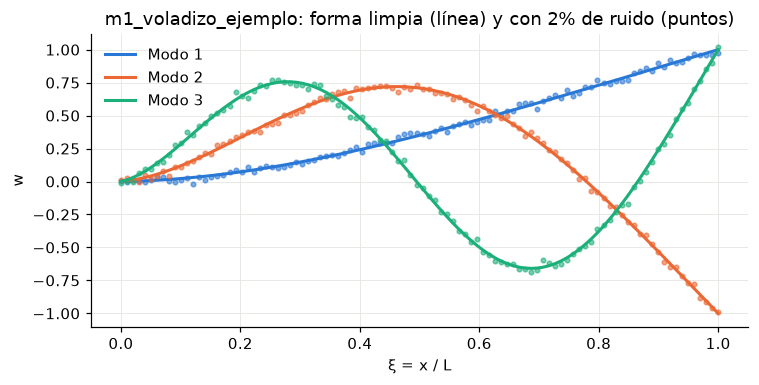

In [8]:
fig, eje = plt.subplots(figsize=(7, 3.6))
for m in range(3):
    eje.plot(conjunto.xi, conjunto.w_limpia[m], color=COLORES[m], label=f"Modo {m + 1}")
    eje.plot(conjunto.xi, conjunto.w[m], "o", color=COLORES[m], markersize=3, alpha=0.6)
eje.set_title(f"{conjunto.nombre}: forma limpia (línea) y con 2% de ruido (puntos)")
eje.set_xlabel("ξ = x / L")
eje.set_ylabel("w")
eje.legend(frameon=False)
fig.tight_layout()

### Formato estándar (`.npz`)

| Campo | Contenido |
|---|---|
| `xi` | puntos de muestreo en [0, 1] |
| `w`, `w_limpia` | formas modales con y sin ruido, (n_modos, n_puntos) |
| `omega` | ω₁…ωₙ en rad/s |
| `estructura`, `generador` | `voladizo`/`biempotrada`, `M0`/`M1` |
| `params`, `ruido`, `config` | JSON: material, geometría, soporte, nivel, semilla, config original |
| `version` | commit de git del generador |

In [9]:
import tempfile

with tempfile.TemporaryDirectory() as tmp:
    copia = Conjunto.cargar(conjunto.guardar(Path(tmp) / "prueba.npz"))
print("Ida y vuelta idéntica:", np.array_equal(copia.w, conjunto.w) and copia.params == conjunto.params)

Ida y vuelta idéntica: True


## Siguientes pasos

- **T13:** calibrar los 6 puntos de severidad de M1 (uno en ≈5%), compararlos con los valores de Kobrinsky et al. (2000) y con el ΔL ≈ 12–13 µm del NIST, y guardarlos como configs.
- **T17:** adimensionalización para la PINN. El solver ya trabaja internamente con λ = ω²ρAL⁴/EI, n = NL²/EI y κ.
- **T37 (semana 7):** generadores M2 (Timoshenko) y M3 (espesor variable).